# Two-Stage NSBH Impact Test (Shared Physics Assumption)

This notebook enforces the assumption that **all prompt-emission physics is shared** between BNS and NSBH.

Workflow:
1. **Stage 1 (BNS-only):** run MCMC with free parameters \((A, L_0, \mu_E, \sigma_E, \theta_c^{\mathrm{BNS}}, f_j^{\mathrm{BNS}})\).
2. Freeze spectral parameters \((A, L_0, \mu_E, \sigma_E)\) at Stage-1 posterior medians.
3. **Stage 2 (BNS+NSBH):** run MCMC only on \((\theta_c^{\mathrm{BNS}}, \theta_c^{\mathrm{NSBH}}, f_j^{\mathrm{BNS}})\).
4. Compare posteriors and inspect geometric-factor correlations.

This isolates the effect of adding NSBH rates without allowing the spectral block (especially \(L_0\)) to absorb rate tension.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import emcee

import sys
sys.path.insert(0, '..')

plt.style.use('../configurations/style.mplstyle')
datafiles = Path('../datafiles')

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
import src.init

print('Imports complete.')

Imports complete.


In [2]:
# Shared population setup (same base physics assumption for both channels)
demo_params = {
    'alpha': -0.6,
    'beta_s': -2.5,
    'n': 2.0,
    'theta_c': 3.4,
    'theta_v_max': 10.0,
    'z_model'       : 'fiducial_delayed_A0.5',
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles=datafiles,
    params=demo_params,
    size_test=2_000,
    nsbh_population='fiducial_delayed_cut',
    nsbh_alpha='A0.5',
)

k_interpolator = create_k_interpolator()
bns_distances = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

print(f'FJ_NSBH fixed = {FJ_NSBH_FIXED}')
print(f'BNS population size  = {len(bns_params.z_arr)}')
print(f'NSBH population size = {len(nsbh_data.z_arr)}')
print(f'Observed yearly GRB rate = {bns_params.yearly_rate:.2f}')

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
FJ_NSBH fixed = 1
BNS population size  = 60187
NSBH population size = 18332
Observed yearly GRB rate = 18.58


## Stage 1: BNS-only Free-Parameter Inference

Free parameters:
- \(A_{\mathrm{index}}, L_{L0}, L_{\mu_E}, \sigma_E\)
- \(\theta_c^{\mathrm{BNS}}, f_j^{\mathrm{BNS}}\)

Likelihood uses only BNS contribution.

In [3]:
# ---- Stage 1 settings ----
N_PARAMS_1  = 6
N_WALKERS_1 = 24
N_STEPS_1   = 10_000

run_name_stage1 = 'two_stage_stage1_bns_only'
out_dir_stage1 = src.init.create_run_dir(run_name_stage1, output_files_default='Output_files')
backend_path_stage1 = out_dir_stage1 / 'emcee.h5'

def log_likelihood_stage1_bns_only(thetas, n_events=N_MC_EVENTS):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, fj_bns = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
    epsilon_bns = geom_eff_bns * fj_bns
    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    pflux_det = bns_results['p_flux'][bns_analysis]
    epeak_det = bns_results['E_p_obs'][bns_analysis]
    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_bns <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_bns)
    logL_total = logL_pflux + logL_epeak + logL_poisson

    return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns

def log_prior_stage1(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, fj_bns = thetas

    if not (1.5 < A_index < 12):
        return -np.inf
    if not (-2 < L_L0 < 7):
        return -np.inf
    if not (0.1 < L_mu_E < 7):
        return -np.inf
    if not (0 < sigma_E < 2.5):
        return -np.inf
    if not (1 < theta_c_bns < 50):
        return -np.inf
    if not (0.01 < fj_bns <= 1.0):
        return -np.inf

    return 0.0

def init_walkers_stage1(n_walkers, seed=123):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(2.0, 3.5, n_walkers),
        rng.uniform(2.0, 4.5, n_walkers),
        rng.uniform(1.5, 4.5, n_walkers),
        rng.uniform(0.2, 1.2, n_walkers),
        rng.uniform(3.0, 20.0, n_walkers),
        rng.uniform(0.1, 0.95, n_walkers),
    ])

def log_probability_stage1(thetas):
    lp = log_prior_stage1(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0, 0.0

    ll = log_likelihood_stage1_bns_only(thetas=thetas, n_events=N_MC_EVENTS)
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3], ll[4]

initial_pos_1, n_steps_rem_1, backend_1 = check_and_resume_mcmc(
    filename=backend_path_stage1,
    n_steps=N_STEPS_1,
    initialize_walkers_func=init_walkers_stage1,
    n_walkers=N_WALKERS_1,
)

print(f'Stage 1 backend: {backend_path_stage1}')
sampler_1 = run_mcmc(
    log_probability_func=log_probability_stage1,
    initial_walkers=initial_pos_1,
    n_iterations=n_steps_rem_1,
    n_walkers=N_WALKERS_1,
    n_params=N_PARAMS_1,
    backend=backend_1,
    blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float)],
)
print(f'Stage 1 done: {backend_1.iteration} total steps saved.')

Loading existing directory  : Output_files/two_stage_stage1_bns_only
Already completed this run
Stage 1 backend: Output_files/two_stage_stage1_bns_only/emcee.h5


0it [00:00, ?it/s]

Stage 1 done: 10000 total steps saved.


In [4]:
# Extract Stage 1 posteriors and freeze spectral parameters
burn_frac = 0.33
thin = 10

flat_1 = backend_1.get_chain(discard=int(backend_1.iteration * burn_frac), thin=thin, flat=True)

param_names_1 = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c_bns', 'fj_bns']
medians_1 = np.median(flat_1, axis=0)

spectral_fixed = medians_1[:4].copy()
theta_bns_stage1_med = medians_1[4]
fj_bns_stage1_med = medians_1[5]

print('Stage 1 posterior medians:')
for n, v in zip(param_names_1, medians_1):
    print(f'  {n:>12s} = {v:.4f}')

print('\nFixed spectral block for Stage 2:')
print(f'  A_index={spectral_fixed[0]:.4f}, L_L0={spectral_fixed[1]:.4f}, L_mu_E={spectral_fixed[2]:.4f}, sigma_E={spectral_fixed[3]:.4f}')

Stage 1 posterior medians:
       A_index = 7.3850
          L_L0 = 3.2048
        L_mu_E = 3.3774
       sigma_E = 0.3726
   theta_c_bns = 15.6904
        fj_bns = 0.3915

Fixed spectral block for Stage 2:
  A_index=7.3850, L_L0=3.2048, L_mu_E=3.3774, sigma_E=0.3726


## Stage 2: Add NSBH While Spectral Block Is Frozen

Free parameters now:
- \(\theta_c^{\mathrm{BNS}}\)
- \(\theta_c^{\mathrm{NSBH}}\)
- \(f_j^{\mathrm{BNS}}\)

Spectral terms are fixed to Stage-1 medians, so any posterior shifts come from rate/geometric coupling, not a re-fit of prompt-emission spectral physics.

In [5]:
# ---- Stage 2 settings ----
N_PARAMS_2  = 3
N_WALKERS_2 = 24
N_STEPS_2   = 10_000

run_name_stage2 = 'two_stage_stage2_bns_plus_nsbh_fixed_spectral'
out_dir_stage2 = src.init.create_run_dir(run_name_stage2, output_files_default='Output_files')
backend_path_stage2 = out_dir_stage2 / 'emcee.h5'

def log_likelihood_stage2_fixed_spectral(thetas, spectral_fixed, n_events=N_MC_EVENTS):
    theta_c_bns, theta_c_nsbh, fj_bns = thetas
    A_index, L_L0, L_mu_E, sigma_E = spectral_fixed
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
    geom_eff_nsbh = geometric_efficiency_fixed(theta_c_nsbh)

    epsilon_bns = geom_eff_bns * fj_bns
    epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED

    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
    intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    nsbh_results = simplified_montecarlo(
        grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
    )
    nsbh_trig, nsbh_analysis = apply_detection_cuts(
        nsbh_results['p_flux'], nsbh_results['E_p_obs']
    )

    pflux_det = np.concatenate([
        bns_results['p_flux'][bns_analysis],
        nsbh_results['p_flux'][nsbh_analysis],
    ])
    epeak_det = np.concatenate([
        bns_results['E_p_obs'][bns_analysis],
        nsbh_results['E_p_obs'][nsbh_analysis],
    ])

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    phys_eff_nsbh = np.sum(nsbh_trig) / n_events

    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
    predicted_nsbh = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh
    predicted_total = predicted_bns + predicted_nsbh

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_total <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
    logL_total = logL_pflux + logL_epeak + logL_poisson

    return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns, predicted_nsbh

def log_prior_stage2(thetas):
    theta_c_bns, theta_c_nsbh, fj_bns = thetas

    if not (1 < theta_c_bns < 50):
        return -np.inf
    if not (1 < theta_c_nsbh < 50):
        return -np.inf
    if not (0.01 < fj_bns <= 1.0):
        return -np.inf

    return 0.0

def init_walkers_stage2(n_walkers, seed=321):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(max(1.2, theta_bns_stage1_med * 0.6), min(45.0, theta_bns_stage1_med * 1.4), n_walkers),
        rng.uniform(2.0, 25.0, n_walkers),
        rng.uniform(max(0.05, fj_bns_stage1_med * 0.5), min(1.0, fj_bns_stage1_med * 1.5), n_walkers),
    ])

def log_probability_stage2(thetas):
    lp = log_prior_stage2(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0

    ll = log_likelihood_stage2_fixed_spectral(
        thetas=thetas,
        spectral_fixed=spectral_fixed,
        n_events=N_MC_EVENTS,
    )
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3], ll[4], ll[5]

initial_pos_2, n_steps_rem_2, backend_2 = check_and_resume_mcmc(
    filename=backend_path_stage2,
    n_steps=N_STEPS_2,
    initialize_walkers_func=init_walkers_stage2,
    n_walkers=N_WALKERS_2,
)

print(f'Stage 2 backend: {backend_path_stage2}')
sampler_2 = run_mcmc(
    log_probability_func=log_probability_stage2,
    initial_walkers=initial_pos_2,
    n_iterations=n_steps_rem_2,
    n_walkers=N_WALKERS_2,
    n_params=N_PARAMS_2,
    backend=backend_2,
    blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float), ('mu_nsbh', float)],
)
print(f'Stage 2 done: {backend_2.iteration} total steps saved.')

Loading existing directory  : Output_files/two_stage_stage2_bns_plus_nsbh_fixed_spectral
Already completed this run
Stage 2 backend: Output_files/two_stage_stage2_bns_plus_nsbh_fixed_spectral/emcee.h5


0it [00:00, ?it/s]

Stage 2 done: 10000 total steps saved.


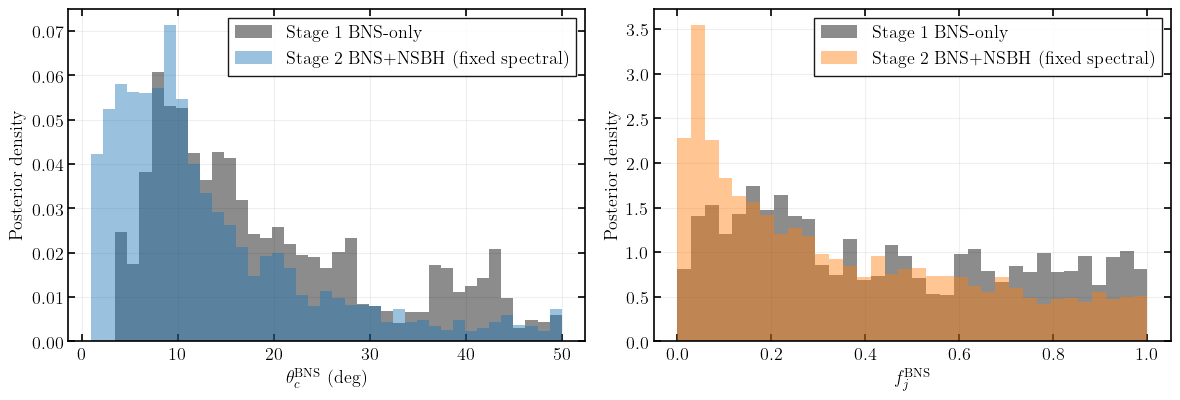

Median theta_c^BNS Stage 1 = 15.690 deg
Median theta_c^BNS Stage 2 = 9.911 deg
Median fj^BNS Stage 1      = 0.392
Median fj^BNS Stage 2      = 0.265


In [6]:
# Compare BNS angle and fj between Stage 1 and Stage 2
flat_2 = backend_2.get_chain(discard=int(backend_2.iteration * burn_frac), thin=thin, flat=True)

theta_bns_1 = flat_1[:, 4]
fj_bns_1 = flat_1[:, 5]

theta_bns_2 = flat_2[:, 0]
theta_nsbh_2 = flat_2[:, 1]
fj_bns_2 = flat_2[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

bins_theta = np.linspace(1, 50, 40)
axes[0].hist(theta_bns_1, bins=bins_theta, density=True, alpha=0.45, label='Stage 1 BNS-only', color='black')
axes[0].hist(theta_bns_2, bins=bins_theta, density=True, alpha=0.45, label='Stage 2 BNS+NSBH (fixed spectral)', color='C0')
axes[0].set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
axes[0].set_ylabel('Posterior density')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

bins_fj = np.linspace(0, 1, 35)
axes[1].hist(fj_bns_1, bins=bins_fj, density=True, alpha=0.45, label='Stage 1 BNS-only', color='black')
axes[1].hist(fj_bns_2, bins=bins_fj, density=True, alpha=0.45, label='Stage 2 BNS+NSBH (fixed spectral)', color='C1')
axes[1].set_xlabel(r'$f_j^{\mathrm{BNS}}$')
axes[1].set_ylabel('Posterior density')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Median theta_c^BNS Stage 1 = {np.median(theta_bns_1):.3f} deg')
print(f'Median theta_c^BNS Stage 2 = {np.median(theta_bns_2):.3f} deg')
print(f'Median fj^BNS Stage 1      = {np.median(fj_bns_1):.3f}')
print(f'Median fj^BNS Stage 2      = {np.median(fj_bns_2):.3f}')

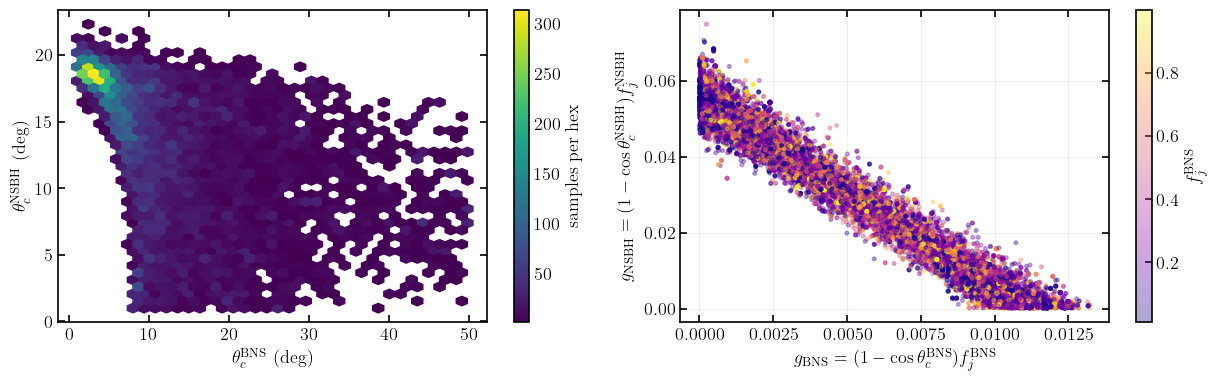

corr(theta_bns, theta_nsbh) = -0.4706
corr(g_bns, g_nsbh)         = -0.9776


In [7]:
# Geometric-factor correlation diagnostics
# g_BNS  = (1 - cos(theta_BNS)) * fj_BNS
# g_NSBH = (1 - cos(theta_NSBH)) * fj_NSBH_fixed

g_bns_1 = geometric_efficiency_fixed(theta_bns_1) * fj_bns_1

g_bns_2 = geometric_efficiency_fixed(theta_bns_2) * fj_bns_2
g_nsbh_2 = geometric_efficiency_fixed(theta_nsbh_2) * FJ_NSBH_FIXED
g_total_2 = g_bns_2 + g_nsbh_2

corr_g = np.corrcoef(g_bns_2, g_nsbh_2)[0, 1]
corr_theta = np.corrcoef(theta_bns_2, theta_nsbh_2)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

ax = axes[0]
hb = ax.hexbin(theta_bns_2, theta_nsbh_2, gridsize=35, mincnt=1, cmap='viridis')
fig.colorbar(hb, ax=ax, label='samples per hex')
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_ylabel(r'$\theta_c^{\mathrm{NSBH}}$ (deg)')

ax = axes[1]
sc = ax.scatter(g_bns_2, g_nsbh_2, c=fj_bns_2, s=7, alpha=0.35, cmap='plasma')
fig.colorbar(sc, ax=ax, label=r'$f_j^{\mathrm{BNS}}$')
ax.set_xlabel(r'$g_{\mathrm{BNS}} = (1-\cos\theta_c^{\mathrm{BNS}})f_j^{\mathrm{BNS}}$')
ax.set_ylabel(r'$g_{\mathrm{NSBH}} = (1-\cos\theta_c^{\mathrm{NSBH}})f_j^{\mathrm{NSBH}}$')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'corr(theta_bns, theta_nsbh) = {corr_theta:.4f}')
print(f'corr(g_bns, g_nsbh)         = {corr_g:.4f}')